# FinTracker — Analisi Finanziaria del Portafoglio

Questo notebook analizza le performance dei titoli presenti nella watchlist di FinTracker.  
Include analisi dei rendimenti, del rischio, delle correlazioni e un backtest della strategia RSI.

**Autore:** Scansani Elia  
**Data:** 2026

In [5]:
# Importazione librerie
import sys
import os

# Aggiunge la root del progetto al path
sys.path.append(os.path.dirname(os.path.abspath(".")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

# Stile dei grafici
plt.style.use("dark_background")
sns.set_palette("husl")

# Impostazioni display
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", 20)

print("✅ Librerie importate correttamente")
print(f"📅 Data analisi: {datetime.now().strftime('%d/%m/%Y')}")

✅ Librerie importate correttamente
📅 Data analisi: 07/05/2026


In [11]:
# Connessione al database PostgreSQL per leggere i ticker in watchlist
import psycopg2
import psycopg2.extras
from dotenv import load_dotenv

cartella_progetto = os.path.abspath(os.path.join(os.getcwd()))
env_path = os.path.join(cartella_progetto, ".env")
load_dotenv(env_path)

def get_watchlist_db():
    """Legge i ticker dalla watchlist di FinTracker."""
    conn = psycopg2.connect(
        host=os.getenv("DB_HOST", "localhost"),
        port=os.getenv("DB_PORT", "5432"),
        dbname=os.getenv("DB_NAME", "fintracker"),
        user=os.getenv("DB_USER", "postgres"),
        password=os.getenv("DB_PASSWORD")
    )
    cursor = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
    cursor.execute("SELECT ticker, nome FROM watchlist ORDER BY data_aggiunta")
    righe = [dict(r) for r in cursor.fetchall()]
    conn.close()
    return righe

watchlist = get_watchlist_db()
tickers   = [r["ticker"] for r in watchlist]
nomi      = {r["ticker"]: r["nome"] for r in watchlist}

print(f"📋 Ticker in watchlist: {len(tickers)}")
for t in watchlist:
    print(f"   {t['ticker']:<10} {t['nome']}")

📋 Ticker in watchlist: 5
   DRS        Leonardo DRS, Inc.
   AAPL       Apple Inc.
   GC=F       Gold Jun 26
   TSLA       Tesla, Inc.
   AMZN       Amazon.com, Inc.


In [14]:
# Scarica 2 anni di dati storici per ogni ticker
PERIODO = "2y"

print(f"📡 Scaricando {PERIODO} di dati storici...")
print("-" * 40)

dati = {}
for ticker in tickers:
    try:
        df = yf.Ticker(ticker).history(period=PERIODO, interval="1d")
        if not df.empty:
            dati[ticker] = df
            print(f"  ✅ {ticker:<10} {len(df)} giorni di dati")
        else:
            print(f"  ⚠️  {ticker:<10} nessun dato disponibile")
    except Exception as e:
        print(f"  ❌ {ticker:<10} errore: {e}")

print("-" * 40)
print(f"✅ Dati scaricati per {len(dati)}/{len(tickers)} ticker")

📡 Scaricando 2y di dati storici...
----------------------------------------
  ✅ DRS        501 giorni di dati
  ✅ AAPL       501 giorni di dati
  ✅ GC=F       504 giorni di dati
  ✅ TSLA       501 giorni di dati
  ✅ AMZN       501 giorni di dati
----------------------------------------
✅ Dati scaricati per 5/5 ticker


In [15]:
# Costruisce un DataFrame unico con i prezzi di chiusura
# di tutti i ticker — una colonna per ticker, una riga per giorno

prezzi = pd.DataFrame({
    ticker: df["Close"]
    for ticker, df in dati.items()
})

# Rimuove giorni in cui tutti i mercati erano chiusi
prezzi = prezzi.dropna(how="all")

print(f"📊 Tabella prezzi: {prezzi.shape[0]} giorni × {prezzi.shape[1]} ticker")
print(f"   Dal: {prezzi.index[0].strftime('%d/%m/%Y')}")
print(f"   Al:  {prezzi.index[-1].strftime('%d/%m/%Y')}")
print()
print(prezzi.tail())

📊 Tabella prezzi: 504 giorni × 5 ticker
   Dal: 07/05/2024
   Al:  07/05/2026

                            DRS   AAPL    GC=F   TSLA   AMZN
Date                                                        
2026-05-01 00:00:00-04:00 40.03 280.14 4629.90 390.82 268.26
2026-05-04 00:00:00-04:00 40.00 276.83 4519.50 392.51 272.05
2026-05-05 00:00:00-04:00 39.70 284.18 4555.80 389.37 273.55
2026-05-06 00:00:00-04:00 41.79 287.51 4681.90 398.73 274.99
2026-05-07 00:00:00-04:00   NaN    NaN 4757.10    NaN    NaN


In [16]:
# ─────────────────────────────────────────────
# ANALISI RENDIMENTI
# ─────────────────────────────────────────────
# I rendimenti giornalieri misurano la variazione percentuale
# del prezzo da un giorno all'altro.
# pct_change() calcola: (prezzo_oggi - prezzo_ieri) / prezzo_ieri

rendimenti = prezzi.pct_change().dropna()

# Rendimento cumulativo — quanto ha reso ogni titolo dall'inizio
# cumprod() moltiplica i rendimenti giornalieri nel tempo
# (1 + r1) * (1 + r2) * ... - 1
rendimento_cumulativo = (1 + rendimenti).cumprod() - 1

print("📈 RENDIMENTO TOTALE NEL PERIODO")
print("-" * 40)
for ticker in tickers:
    if ticker in rendimento_cumulativo.columns:
        rend = rendimento_cumulativo[ticker].iloc[-1] * 100
        emoji = "🟢" if rend > 0 else "🔴"
        print(f"  {emoji} {ticker:<10} {rend:+.2f}%")

📈 RENDIMENTO TOTALE NEL PERIODO
----------------------------------------
  🟢 DRS        +93.31%
  🟢 AAPL       +65.78%
  🟢 GC=F       +98.90%
  🟢 TSLA       +140.70%
  🟢 AMZN       +47.77%


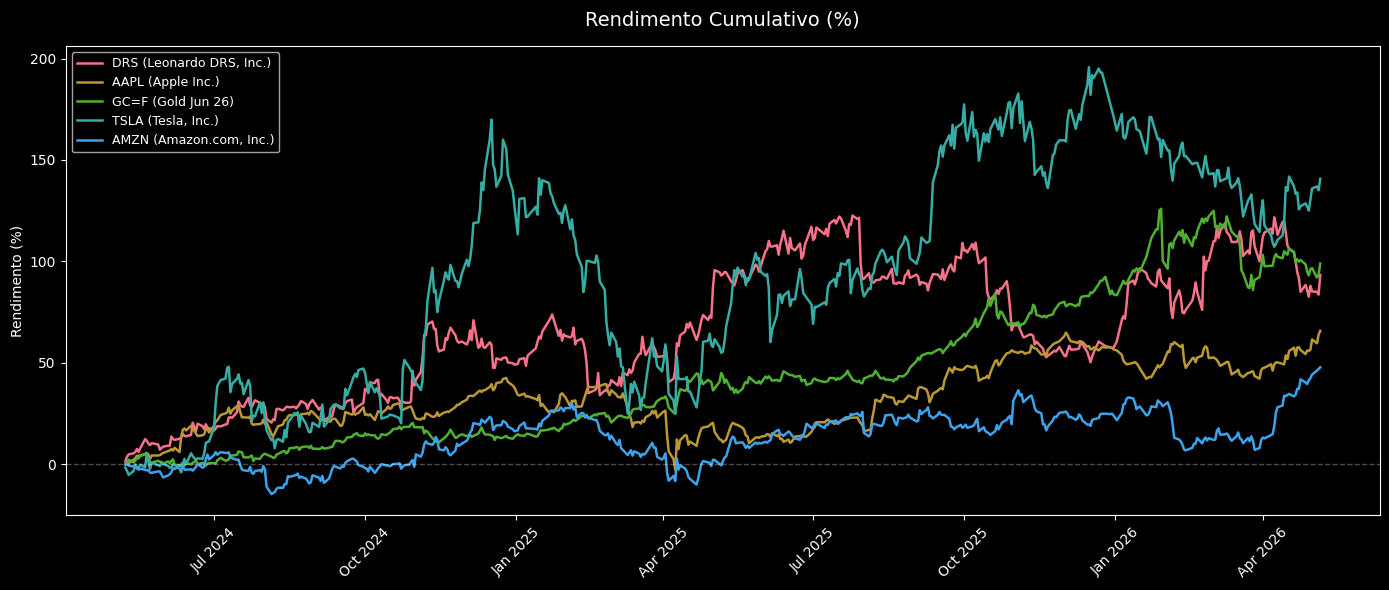

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

for ticker in rendimento_cumulativo.columns:
    ax.plot(
        rendimento_cumulativo.index,
        rendimento_cumulativo[ticker] * 100,
        label=f"{ticker} ({nomi.get(ticker, '')})",
        linewidth=1.8
    )

# Linea dello zero — riferimento visivo per capire
# se un titolo è in guadagno o in perdita
ax.axhline(y=0, color="white", linestyle="--", alpha=0.3, linewidth=1)

ax.set_title("Rendimento Cumulativo (%)", fontsize=14, pad=15)
ax.set_ylabel("Rendimento (%)")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Ricampiona i prezzi a frequenza mensile
# resample("ME") raggruppa per mese prendendo l'ultimo giorno
rendimenti_mensili = prezzi.resample("ME").last().pct_change().dropna() * 100

print("📅 STATISTICHE RENDIMENTI MENSILI")
print("=" * 60)

stats = pd.DataFrame({
    "Media %":    rendimenti_mensili.mean(),
    "Mediana %":  rendimenti_mensili.median(),
    "Miglior mese %":  rendimenti_mensili.max(),
    "Peggior mese %":  rendimenti_mensili.min(),
    "Mesi positivi":   (rendimenti_mensili > 0).sum(),
    "Mesi negativi":   (rendimenti_mensili < 0).sum(),
}).round(2)

print(stats.to_string())

📅 STATISTICHE RENDIMENTI MENSILI
      Media %  Mediana %  Miglior mese %  Peggior mese %  Mesi positivi  Mesi negativi
DRS      2.94       4.26           20.45          -19.47             16              8
AAPL     1.87       2.37           11.96           -8.15             16              8
GC=F     3.15       3.38           10.96          -11.14             18              6
TSLA     4.44       2.66           38.15          -27.59             14             10
AMZN     2.22       1.86           27.27          -12.24             13             11


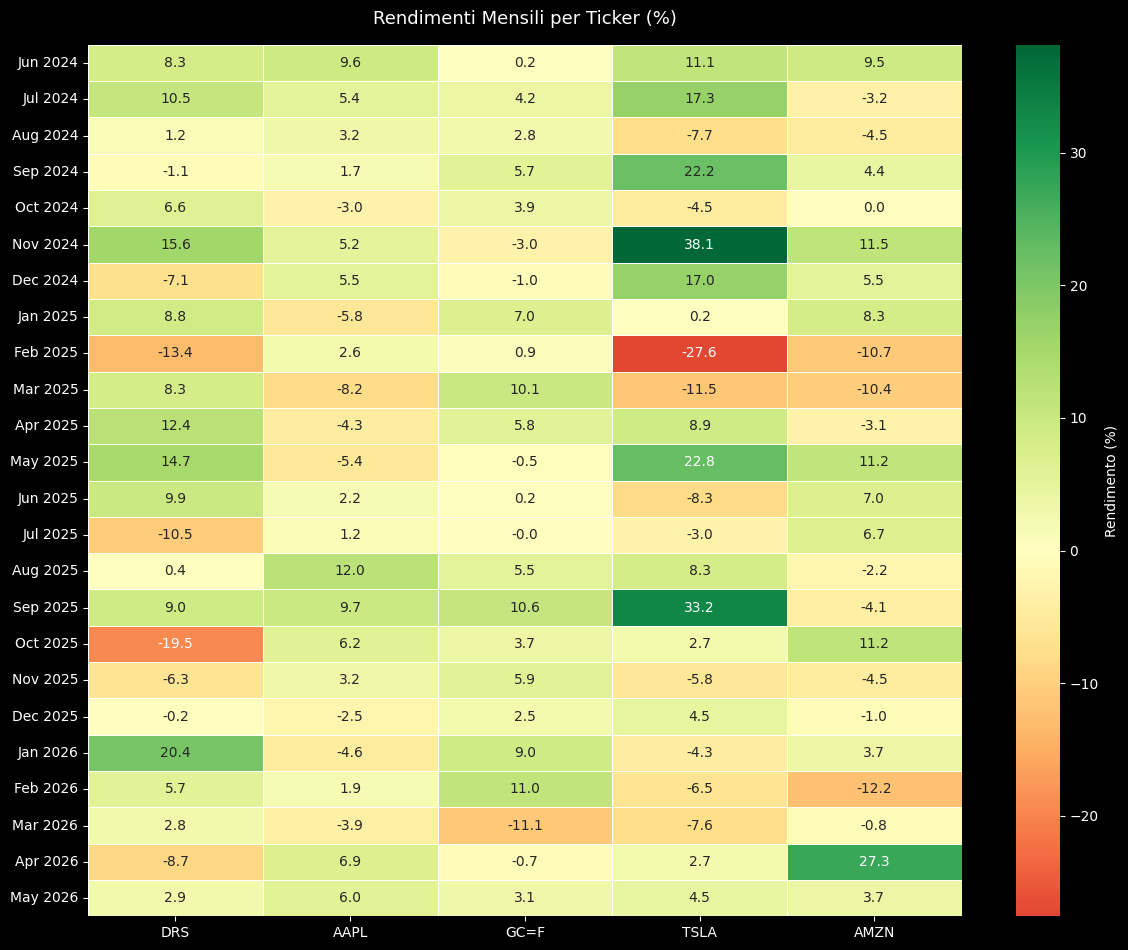

In [19]:
# Crea una heatmap per visualizzare i rendimenti mese per mese
# Ogni riga è un mese, ogni colonna è un ticker
# Verde = rendimento positivo, Rosso = rendimento negativo

rendimenti_pivot = rendimenti_mensili.copy()
rendimenti_pivot.index = rendimenti_pivot.index.strftime("%b %Y")

fig, ax = plt.subplots(figsize=(12, max(6, len(rendimenti_pivot) * 0.4)))

sns.heatmap(
    rendimenti_pivot,
    annot=True,          # Mostra i valori nelle celle
    fmt=".1f",           # Un decimale
    cmap="RdYlGn",       # Rosso = negativo, Verde = positivo
    center=0,            # Zero = colore neutro
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Rendimento (%)"}
)

ax.set_title("Rendimenti Mensili per Ticker (%)", fontsize=13, pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [20]:
# ─────────────────────────────────────────────
# ANALISI DEL RISCHIO
# ─────────────────────────────────────────────
# La volatilità misura quanto oscilla il prezzo di un titolo.
# Si calcola come deviazione standard dei rendimenti giornalieri
# annualizzata (moltiplicata per √252, i giorni di borsa aperta in un anno).
# Alta volatilità = alto rischio ma anche alte opportunità.

giorni_anno = 252

volatilita_giornaliera = rendimenti.std()
volatilita_annuale     = volatilita_giornaliera * np.sqrt(giorni_anno) * 100

rendimento_annuale = rendimenti.mean() * giorni_anno * 100

# Sharpe Ratio — misura il rendimento ottenuto per ogni unità di rischio
# Sharpe > 1 = buon rapporto rischio/rendimento
# Sharpe > 2 = eccellente
# Sharpe < 0 = il titolo ha perso denaro
tasso_privo_rischio = 4.5  # Tasso dei BTP italiani a 10 anni (%)
sharpe = (rendimento_annuale - tasso_privo_rischio) / volatilita_annuale

print("📊 ANALISI RISCHIO/RENDIMENTO")
print("=" * 65)
print(f"{'  Ticker':<10} {'\t Rend. annuo':>12} {'\t Volatilità':>12} {'\tSharpe':>10}")
print("-" * 65)

for ticker in tickers:
    if ticker in rendimento_annuale.index:
        r = rendimento_annuale[ticker]
        v = volatilita_annuale[ticker]
        s = sharpe[ticker]
        emoji = "🟢" if s > 1 else "🟡" if s > 0 else "🔴"
        print(f"  {emoji} {ticker:<8} {r:>+11.2f}% {v:>11.2f}%   {s:>10.2f}")

print("-" * 65)
print(f"\n💡 Sharpe > 1 = buon rapporto rischio/rendimento")
print(f"   Tasso privo di rischio usato: {tasso_privo_rischio}% (BTP 10 anni)")

📊 ANALISI RISCHIO/RENDIMENTO
  Ticker   	 Rend. annuo 	 Volatilità    	Sharpe
-----------------------------------------------------------------
  🟡 DRS           +41.57%       40.57%         0.91
  🟡 AAPL          +29.52%       28.17%         0.89
  🟢 GC=F          +37.51%       23.07%         1.43
  🟡 TSLA          +62.67%       60.77%         0.96
  🟡 AMZN          +24.92%       32.17%         0.63
-----------------------------------------------------------------

💡 Sharpe > 1 = buon rapporto rischio/rendimento
   Tasso privo di rischio usato: 4.5% (BTP 10 anni)


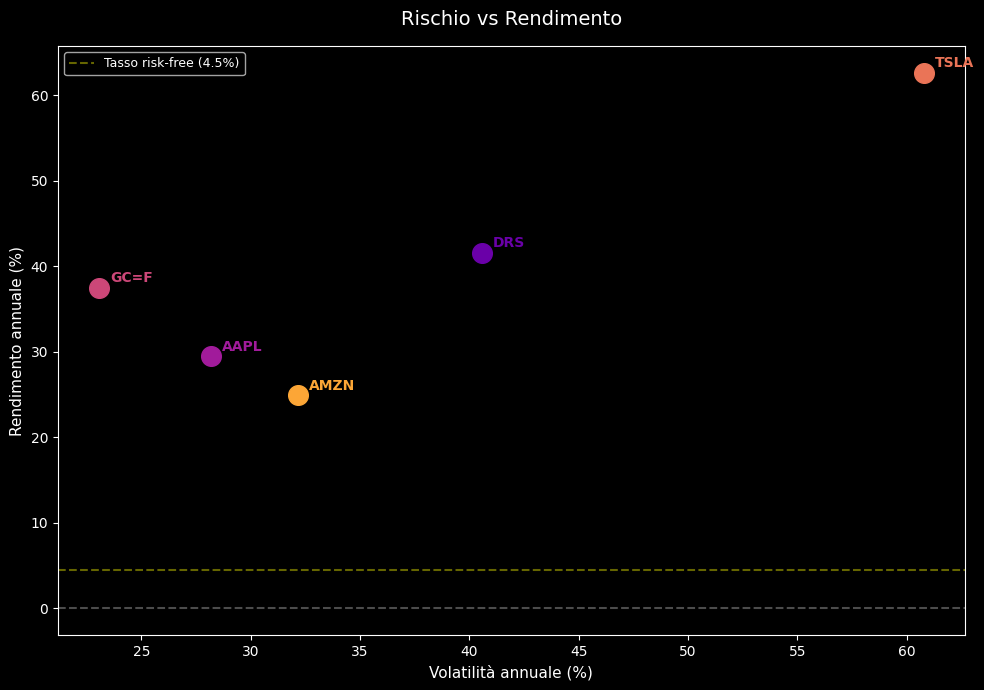


💡 Titoli in alto a sinistra = miglior rapporto rischio/rendimento


In [21]:
# Scatter plot rischio vs rendimento
# Ogni punto è un ticker — vuoi titoli in alto a sinistra
# (alto rendimento, bassa volatilità)

fig, ax = plt.subplots(figsize=(10, 7))

colori = plt.cm.plasma(np.linspace(0.2, 0.8, len(tickers)))

for i, ticker in enumerate(tickers):
    if ticker not in rendimento_annuale.index:
        continue

    r = rendimento_annuale[ticker]
    v = volatilita_annuale[ticker]
    s = sharpe[ticker]

    ax.scatter(v, r, s=200, color=colori[i], zorder=5)
    ax.annotate(
        ticker,
        (v, r),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=10,
        color=colori[i],
        fontweight="bold"
    )

# Linee di riferimento
ax.axhline(y=0, color="white", linestyle="--", alpha=0.3)
ax.axhline(y=tasso_privo_rischio, color="yellow",
           linestyle="--", alpha=0.4, label=f"Tasso risk-free ({tasso_privo_rischio}%)")

ax.set_xlabel("Volatilità annuale (%)", fontsize=11)
ax.set_ylabel("Rendimento annuale (%)", fontsize=11)
ax.set_title("Rischio vs Rendimento", fontsize=14, pad=15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n💡 Titoli in alto a sinistra = miglior rapporto rischio/rendimento")

In [22]:
# ─────────────────────────────────────────────
# ANALISI CORRELAZIONI
# ─────────────────────────────────────────────
# La correlazione misura quanto due titoli si muovono insieme.
# +1.0 = si muovono sempre nella stessa direzione
#  0.0 = movimenti indipendenti
# -1.0 = si muovono sempre in direzioni opposte
#
# Per un portafoglio diversificato vuoi titoli
# con bassa correlazione tra loro.

correlazioni = rendimenti.corr()

print("🔗 MATRICE DI CORRELAZIONE")
print(correlazioni.round(2).to_string())
print()

# Trova le coppie più correlate
print("📌 COPPIE PIÙ CORRELATE (esclude autocorrelazione):")
coppie = []
for i in range(len(correlazioni.columns)):
    for j in range(i + 1, len(correlazioni.columns)):
        t1 = correlazioni.columns[i]
        t2 = correlazioni.columns[j]
        c  = correlazioni.iloc[i, j]
        coppie.append((t1, t2, c))

coppie.sort(key=lambda x: abs(x[2]), reverse=True)
for t1, t2, c in coppie[:5]:
    emoji = "🔴" if abs(c) > 0.7 else "🟡" if abs(c) > 0.4 else "🟢"
    print(f"  {emoji} {t1} — {t2}: {c:+.2f}")

🔗 MATRICE DI CORRELAZIONE
      DRS  AAPL  GC=F  TSLA  AMZN
DRS  1.00  0.13  0.12  0.30  0.28
AAPL 0.13  1.00  0.03  0.44  0.47
GC=F 0.12  0.03  1.00  0.02 -0.03
TSLA 0.30  0.44  0.02  1.00  0.47
AMZN 0.28  0.47 -0.03  0.47  1.00

📌 COPPIE PIÙ CORRELATE (esclude autocorrelazione):
  🟡 TSLA — AMZN: +0.47
  🟡 AAPL — AMZN: +0.47
  🟡 AAPL — TSLA: +0.44
  🟢 DRS — TSLA: +0.30
  🟢 DRS — AMZN: +0.28


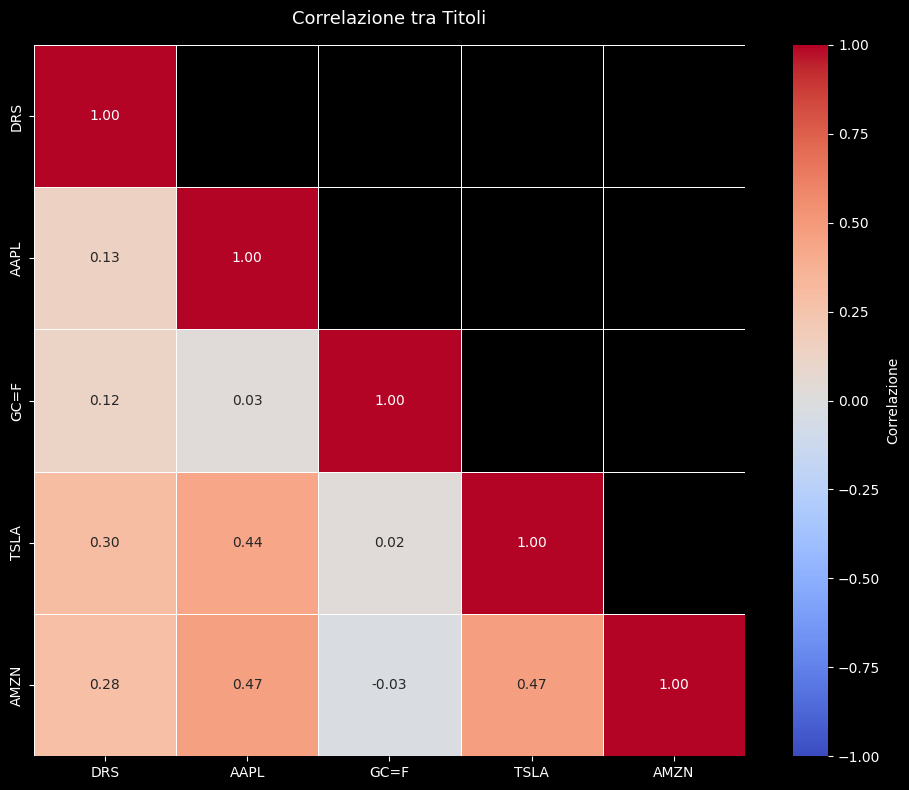


💡 Legenda 💡 
	Rosso = alta correlazione (poca diversificazione)
	Blu   = correlazione negativa (buona diversificazione)


In [25]:
fig, ax = plt.subplots(figsize=(10, 8))

maschera = np.triu(np.ones_like(correlazioni, dtype=bool), k=1)

sns.heatmap(
    correlazioni,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    mask=maschera,        # Mostra solo il triangolo inferiore
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Correlazione"}
)

ax.set_title("Correlazione tra Titoli", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print("\n💡 Legenda 💡 \n\tRosso = alta correlazione (poca diversificazione)")
print("\tBlu   = correlazione negativa (buona diversificazione)")

In [28]:
# ─────────────────────────────────────────────
# BACKTEST STRATEGIA RSI
# ─────────────────────────────────────────────
# Domanda: se avessi comprato ogni volta che RSI < 30
# (ipervenduto) e venduto quando RSI > 70 (ipercomprato),
# quanto avresti guadagnato negli ultimi 2 anni?
#
# Regole della strategia:
# - COMPRA quando RSI scende sotto 30
# - VENDI quando RSI sale sopra 70
# - Possiedi al massimo 1 azione alla volta
# - Capitale iniziale: 10.000€

CAPITALE_INIZIALE = 10000
RSI_COMPRA        = 30
RSI_VENDI         = 70
RSI_PERIODO       = 14

def calcola_rsi(prezzi_close, periodo=14):
    """
    Calcola il RSI su una serie di prezzi.
    Usa la media mobile esponenziale (EWM) — più precisa
    della media semplice per il RSI.
    """
    delta    = prezzi_close.diff()
    guadagni = delta.where(delta > 0, 0.0)
    perdite  = (-delta.where(delta < 0, 0.0))

    media_guadagni = guadagni.ewm(com=periodo - 1, adjust=False).mean()
    media_perdite  = perdite.ewm(com=periodo - 1, adjust=False).mean()

    rs  = media_guadagni / media_perdite
    rsi = 100 - (100 / (1 + rs))
    return rsi


def backtest_rsi(ticker, df_prezzi):
    """
    Esegue il backtest della strategia RSI su un titolo.
    Restituisce un dizionario con tutte le statistiche.
    """
    close = df_prezzi["Close"].copy()
    rsi   = calcola_rsi(close, RSI_PERIODO)

    capitale    = CAPITALE_INIZIALE
    in_posizione = False
    prezzo_acquisto = 0
    operazioni  = []

    for i in range(RSI_PERIODO, len(close)):
        prezzo = close.iloc[i]
        r      = rsi.iloc[i]
        data   = close.index[i]

        # Segnale di ACQUISTO — RSI sotto la soglia e non siamo già investiti
        if r < RSI_COMPRA and not in_posizione:
            azioni          = capitale / prezzo
            prezzo_acquisto = prezzo
            in_posizione    = True
            operazioni.append({
                "tipo":    "COMPRA",
                "data":    data,
                "prezzo":  round(prezzo, 2),
                "rsi":     round(r, 2),
                "azioni":  round(azioni, 4)
            })

        # Segnale di VENDITA — RSI sopra la soglia e siamo investiti
        elif r > RSI_VENDI and in_posizione:
            azioni          = capitale / prezzo_acquisto
            capitale_nuovo  = azioni * prezzo
            profitto        = capitale_nuovo - capitale
            rendimento_op   = (profitto / capitale) * 100

            operazioni.append({
                "tipo":       "VENDI",
                "data":       data,
                "prezzo":     round(prezzo, 2),
                "rsi":        round(r, 2),
                "profitto":   round(profitto, 2),
                "rendimento": round(rendimento_op, 2)
            })

            capitale     = capitale_nuovo
            in_posizione = False

    # Se siamo ancora in posizione alla fine valutiamo al prezzo attuale
    if in_posizione:
        prezzo_attuale = close.iloc[-1]
        azioni         = capitale / prezzo_acquisto
        capitale       = azioni * prezzo_attuale

    rendimento_totale = ((capitale - CAPITALE_INIZIALE) / CAPITALE_INIZIALE) * 100

    # Confronto con Buy & Hold — comprare e tenere per tutto il periodo
    rendimento_buyhold = ((close.iloc[-1] - close.iloc[0]) / close.iloc[0]) * 100

    # Numero di operazioni chiuse (solo le vendite)
    vendite       = [o for o in operazioni if o["tipo"] == "VENDI"]
    op_positive   = [v for v in vendite if v["profitto"] > 0]
    win_rate      = (len(op_positive) / len(vendite) * 100) if vendite else 0

    return {
        "ticker":              ticker,
        "capitale_finale":     round(capitale, 2),
        "rendimento_rsi":      round(rendimento_totale, 2),
        "rendimento_buyhold":  round(rendimento_buyhold, 2),
        "n_operazioni":        len(vendite),
        "win_rate":            round(win_rate, 2),
        "operazioni":          operazioni
    }


# Esegui il backtest per tutti i ticker
print(f"🔬 BACKTEST STRATEGIA RSI ({RSI_COMPRA}/{RSI_VENDI})")
print(f"   Capitale iniziale: {CAPITALE_INIZIALE:,}€")
print(f"   Periodo: 2 anni")
print("=" * 70)

risultati = {}
for ticker in tickers:
    if ticker in dati:
        risultati[ticker] = backtest_rsi(ticker, dati[ticker])

print(f"\n{'Ticker':<10}  {'Capitale finale':>16}  {'RSI Strat.':>12}  {'Buy&Hold':>10}  {'Operaz.':>9}  {'Win Rate':>10}")
print("-" * 70)

for ticker, r in risultati.items():
    emoji_rsi = "🟢" if r["rendimento_rsi"] > 0 else "🔴"
    confronto = "✅" if r["rendimento_rsi"] > r["rendimento_buyhold"] else "❌"
    print(
        f"  {emoji_rsi} {ticker:<8} "
        f"€{r['capitale_finale']:>14,.2f} "
        f"{r['rendimento_rsi']:>+11.2f}% "
        f"{r['rendimento_buyhold']:>+9.2f}% {confronto} "
        f"{r['n_operazioni']:>8} "
        f"{r['win_rate']:>9.1f}%"
    )

print("-" * 70)
print("\n✅ = Strategia RSI batte Buy & Hold | ❌ = Buy & Hold batte RSI")

🔬 BACKTEST STRATEGIA RSI (30/70)
   Capitale iniziale: 10,000€
   Periodo: 2 anni

Ticker       Capitale finale    RSI Strat.    Buy&Hold    Operaz.    Win Rate
----------------------------------------------------------------------
  🟢 DRS      €     14,459.82      +44.60%    +95.14% ❌        2     100.0%
  🟢 AAPL     €     11,326.70      +13.27%    +59.06% ❌        1     100.0%
  🟢 GC=F     €     10,801.53       +8.02%   +105.47% ❌        0       0.0%
  🟢 TSLA     €     11,032.70      +10.33%   +124.24% ❌        1     100.0%
  🟢 AMZN     €     18,754.53      +87.55%    +45.68% ✅        4     100.0%
----------------------------------------------------------------------

✅ = Strategia RSI batte Buy & Hold | ❌ = Buy & Hold batte RSI


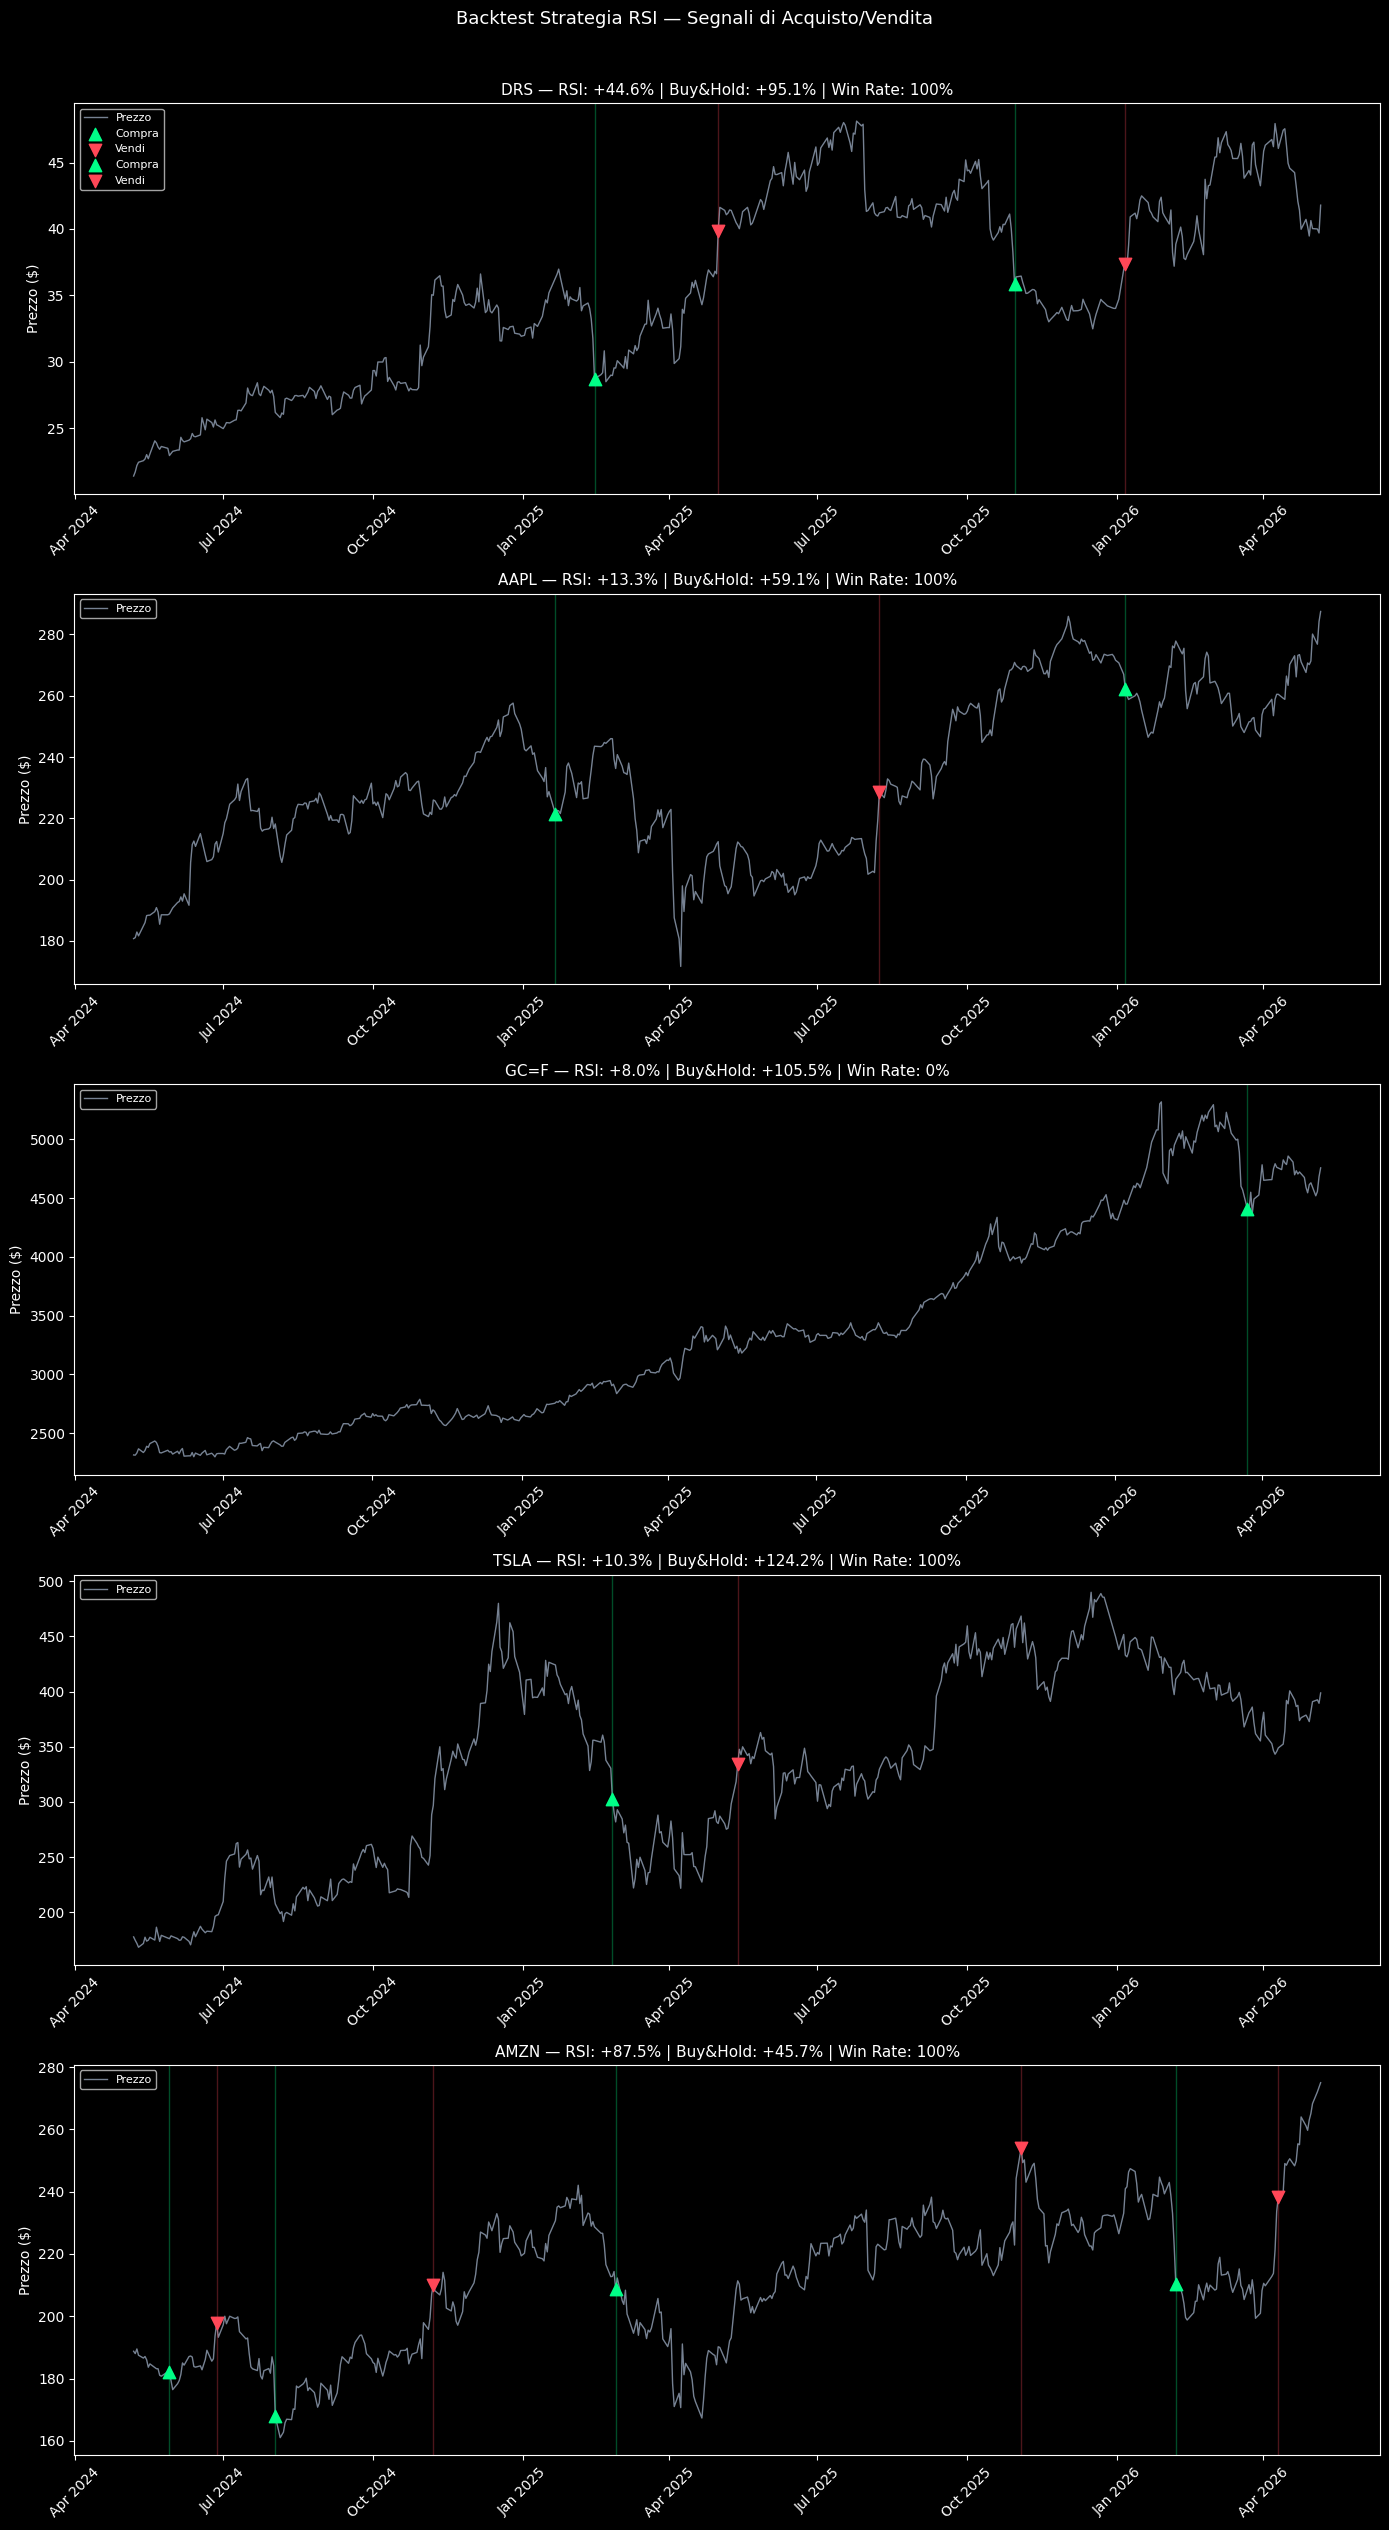

In [29]:
# Visualizza l'andamento del capitale per ogni ticker
fig, axes = plt.subplots(
    len(risultati), 1,
    figsize=(14, 5 * len(risultati)),
    squeeze=False
)

for idx, (ticker, r) in enumerate(risultati.items()):
    ax   = axes[idx][0]
    close = dati[ticker]["Close"]
    rsi   = calcola_rsi(close, RSI_PERIODO)

    # Grafico prezzo
    ax.plot(close.index, close.values, color="#94a3b8",
            linewidth=1, alpha=0.8, label="Prezzo")

    # Evidenzia segnali di acquisto e vendita
    for op in r["operazioni"]:
        if op["tipo"] == "COMPRA":
            ax.axvline(op["data"], color="#00ff87",
                      alpha=0.3, linewidth=1)
            ax.scatter(op["data"], op["prezzo"],
                      color="#00ff87", s=80, zorder=5,
                      marker="^", label="Compra" if idx == 0 else "")
        else:
            ax.axvline(op["data"], color="#ff4757",
                      alpha=0.3, linewidth=1)
            ax.scatter(op["data"], op["prezzo"],
                      color="#ff4757", s=80, zorder=5,
                      marker="v", label="Vendi" if idx == 0 else "")

    titolo = (
        f"{ticker} — RSI: {r['rendimento_rsi']:+.1f}% | "
        f"Buy&Hold: {r['rendimento_buyhold']:+.1f}% | "
        f"Win Rate: {r['win_rate']:.0f}%"
    )
    ax.set_title(titolo, fontsize=11)
    ax.set_ylabel("Prezzo ($)")
    ax.legend(loc="upper left", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle("Backtest Strategia RSI — Segnali di Acquisto/Vendita",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [32]:
# Mostra il dettaglio di ogni operazione per ogni ticker
for ticker, r in risultati.items():
    vendite = [o for o in r["operazioni"] if o["tipo"] == "VENDI"]
    if not vendite:
        print(f"\n{ticker}: nessuna operazione completata")
        continue

    print(f"\n{'='*60}")
    print(f"📋 {ticker} — {len(vendite)} operazioni completate")
    print(f"{'='*60}")
    print(f"  {'Data vendita':<15} {'Prezzo':>8} {'RSI':>6} {'Profitto':>10} {'Rend.':>8}")
    print(f"  {'-'*55}")

    for v in vendite:
        emoji = "✅" if v["profitto"] > 0 else "❌"
        print(
            f"  {emoji} {str(v['data'])[:10]:<13} "
            f"${v['prezzo']:>7.2f} "
            f"{v['rsi']:>6.1f} "
            f"€{v['profitto']:>+9.2f} "
            f"{v['rendimento']:>+7.2f}%"
        )


📋 DRS — 2 operazioni completate
  Data vendita      Prezzo    RSI   Profitto    Rend.
  -------------------------------------------------------
  ✅ 2025-05-01    $  39.87   70.8 € +3879.02  +38.79%
  ✅ 2026-01-06    $  37.39   70.0 €  +580.80   +4.18%

📋 AAPL — 1 operazioni completate
  Data vendita      Prezzo    RSI   Profitto    Rend.
  -------------------------------------------------------
  ✅ 2025-08-08    $ 228.65   73.7 €  +326.23   +3.26%

GC=F: nessuna operazione completata

📋 TSLA — 1 operazioni completate
  Data vendita      Prezzo    RSI   Profitto    Rend.
  -------------------------------------------------------
  ✅ 2025-05-13    $ 334.07   70.0 € +1032.70  +10.33%

📋 AMZN — 4 operazioni completate
  Data vendita      Prezzo    RSI   Profitto    Rend.
  -------------------------------------------------------
  ✅ 2024-06-27    $ 197.85   71.0 €  +869.68   +8.70%
  ✅ 2024-11-07    $ 210.05   71.9 € +2728.75  +25.10%
  ✅ 2025-11-03    $ 254.00   71.8 € +2948.48  +21.68%
  